# Figure XX - mCherry Revisions

## Load data

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import ticker as mticker
import seaborn as sns
import scipy
from statannotations.Annotator import Annotator
import rushd as rd
import re
from pathlib import Path
import matplotlib
from matplotlib.patches import Patch
from matplotlib.colors import LinearSegmentedColormap

# Required descriptors for annotate
from scipy.stats import ttest_ind
from statannotations.stats.StatTest import StatTest
custom_long_name = 't-test for independent samples from scipy with greater 1-way (mean of the distribution underlying the first sample is greater than the mean of the distribution underlying the second sample)'
custom_short_name = 't-test_ind_greater'
custom_func = ttest_ind
ttest_ind_greater = StatTest(custom_func, custom_long_name, custom_short_name, alternative='greater')

custom_long_name = 't-test for independent samples from scipy with less 1-way (mean of the distribution underlying the first sample is less than the mean of the distribution underlying the second sample)'
custom_short_name = 't-test_ind_less'
custom_func = ttest_ind
ttest_ind_less = StatTest(custom_func, custom_long_name, custom_short_name, alternative='less')

In [25]:
alpha_tech_rep = 0.45
alpha_mean = 0.75
markersize = 7

In [2]:
# Set paths to the experiment folder and where to find the data
base_path = rd.datadir/'data'/'attune'/'Mary'

Plates = {'2026.07.10_exp66': ['Plate1', 'Plate2','Plate3']
}

exp_path = []
yaml_path = []

for i in Plates:
    for j in Plates[i]:
        exp_path.append(base_path/i/j/'Single_cell_csvs'/'Single_cell_csvs')
        yaml_path.append(base_path/i/j/'Single_cell_csvs'/'Single_cell_csvs'/'wells.yaml')

output_path = rd.rootdir/'output'/'Figure_XX_mCherry'
cache_path = rd.rootdir/'output'/'Figure_XX_mCherry'/'data.gzip'

plates_dict = pd.DataFrame({
    'data_path' : [exp for exp in exp_path],
    'yaml_path' : [yaml for yaml in yaml_path]
})

display(plates_dict)

,data_path,yaml_path
0,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...
1,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...
2,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...


In [3]:
#Load data
data = pd.DataFrame()
if cache_path.is_file(): data = pd.read_parquet(cache_path)
else:
    channel_list = ['mRuby2-A', 'mRuby2-H','mGL-H','mGL-A', 'iRFP670-A','iRFP670-H', 'FSC-A','TagBFP-A','TagBFP-H']
    data = rd.flow.load_groups_with_metadata(plates_dict,columns=channel_list) #Could add in columns=channel_list here to get specific columns

    # Remove NaN values
    data.dropna(inplace=True)

    # Save data in the cache path for easier loading next time
    data.to_parquet(rd.outfile(cache_path))


In [4]:
data = data.rename(columns={'mRuby2-A': 'mCherry-A', 'mRuby2-H':'mCherry-H'})

## Gating

In [5]:
channel_list = ['mCherry-A', 'mCherry-H','mGL-H','mGL-A', 'iRFP670-A','iRFP670-H', 'TagBFP-A','TagBFP-H']


df_fractions=data.copy()

for channel in channel_list:
    df_fractions.loc[df_fractions[channel] <=0, channel] = 1


In [6]:
df_no_bfp = df_fractions[df_fractions['cond'] == 'none']
bfp_threshold_hard = df_no_bfp['TagBFP-A'].quantile(0.99)
mruby_threshold = 2500

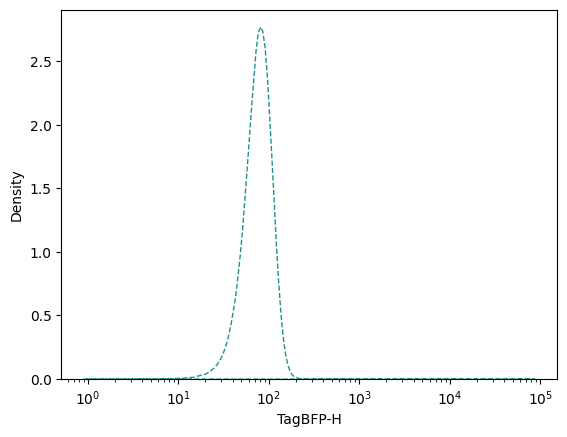

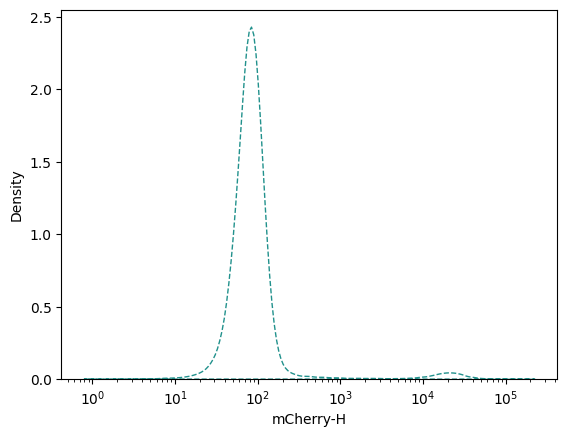

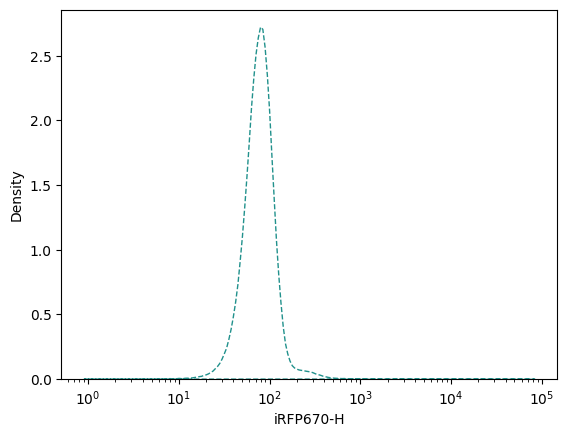

In [7]:
parameters = np.array(['TagBFP-H', 'mCherry-H', 'iRFP670-H'])
for param in parameters:
    untransfected = data[(data['cond'] == 'none')& (data[param] > 0)]
    g = plt.figure()
    sns.kdeplot(untransfected, x=param,hue='cond',log_scale=True,legend=False,fill=True,common_norm=False,palette='viridis', alpha = 0, linestyle = '--')

In [8]:
# Or use the percentile gating
iRFP_gate_quantile = untransfected['iRFP670-H'].quantile(0.99)
TagBFP_gate = 200
mRuby2_gate = 2500
display(iRFP_gate_quantile)

# # Gating on co-transfection marker
data_gated = data[data['iRFP670-H'] > iRFP_gate_quantile]

268.0

In [9]:
TagBFP_gated = data[data['TagBFP-H'] > TagBFP_gate].copy()
TagBFP_gated['mCH_cat'] = np.where(TagBFP_gated['mCherry-H'] > mRuby2_gate, 'mCH+', 'mCH-') 

## Figure mCH - Fluorescent selectivity

In [10]:
well_group = ['cond','biorep','puro']
count_df = TagBFP_gated.groupby(['cond', 'biorep','mCH_cat','puro'])[
    'FSC-A'].count().unstack(fill_value=0).stack().rename('count')
percent_small_data_1_TagBFP = (count_df*100/count_df.groupby(well_group ).transform('sum')).reset_index(name='percent')
count_small_data_1_TagBFP = count_df.reset_index()
display(percent_small_data_1_TagBFP)

,cond,biorep,mCH_cat,puro,percent
0,desNb(mCherry),1,mCH+,0.0,9.589041
1,desNb(mCherry),1,mCH+,2.5,5.521472
2,desNb(mCherry),1,mCH+,5.0,2.500000
3,desNb(mCherry),1,mCH+,10.0,6.722689
4,desNb(mCherry),1,mCH+,20.0,3.053435
...,...,...,...,...,...
125,wtNb(mCherry)-BFP,3,mCH-,0.0,97.844301
126,wtNb(mCherry)-BFP,3,mCH-,2.5,98.078815
127,wtNb(mCherry)-BFP,3,mCH-,5.0,97.887927
128,wtNb(mCherry)-BFP,3,mCH-,10.0,97.943076


C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_14384\3141788042.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_14384\3141788042.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([lmap[cond] for cond in order])


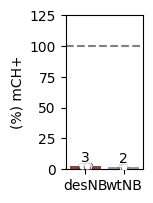

In [11]:
# General plotting params
x = 'cond'
y = 'percent'

# Conditions
order = ['desNb(mCherry)-BFP', 'wtNb(mCherry)-BFP']
mCH_cat = 'mCH+'

df = percent_small_data_1_TagBFP.loc[(percent_small_data_1_TagBFP['mCH_cat'] == mCH_cat) & (percent_small_data_1_TagBFP['puro'] == 0.0)]

palette = {
    'desNb(mCherry)-BFP': 'darkred', 
    'wtNb(mCherry)-BFP': 'grey'
}
fig, ax = plt.subplots(1, 1, figsize=(1,2))

# Plot hyperP percent of all cells
sns.barplot(
    ax=ax, data=df,
    x=x, y=y,
    order=order,
    palette=palette,
    alpha=0.8)

sns.stripplot(
    ax=ax, data=df,
    x=x, y=y,
    order=order,
    dodge=True,
    color='white', size=5,
    edgecolor='black', linewidth=0.4,)



lmap = {
    'desNb(mCherry)-BFP': 'desNB', 
    'wtNb(mCherry)-BFP': 'wtNB'
}
ax.set_xticklabels([lmap[cond] for cond in order])
ax.set_ylim((0, 125))
plt.axhline(y=100, color='grey', linestyle= '--')
ax.yaxis.set_label_text('(%) mCH+')
# ax.set_title('mRuby2+ | 4 dpi (Lenti) | new plasmids')
ax.set_xlabel('')

# Add barplot labels
for sub_ax in plt.gcf().get_axes():
    for i in sub_ax.containers:
        bar_labels = sub_ax.bar_label(i, fmt='%0.0f', padding=1)
        for label in bar_labels:
            label.set_bbox(dict(facecolor='white', alpha=0.75, linewidth=0, pad=1))    

plottitle = 'Figure_XX_mCherry_selectivity.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')

## mCherry and iRFP gating

In [12]:
# Categorize cells based on iRFP670_thresh
data.loc[:, 'iRFP670_cat'] = 'iRFP670-'
data.loc[(data['iRFP670-H'] > iRFP_gate_quantile), 'iRFP670_cat'] = 'iRFP670+'

# Get total counts and percent of GFP-H+
group = [ 'cond', 'biorep', 'puro']
count_df_reps = data.groupby([*group, 'well', 'iRFP670_cat'])[
    'iRFP670-H'].count().unstack(fill_value=0).stack().rename('count') # Puts 0 if no GFP-H+ rather than dropping row
percent_df_reps = (count_df_reps*100/count_df_reps.groupby([*group, 'well']).transform('sum')).reset_index(name='percent')
data_iRFP670_count_reps = count_df_reps.reset_index()

# Extract just the iRFP670+
data_iRFP670_percent_reps = percent_df_reps.loc[(percent_df_reps['iRFP670_cat'] == 'iRFP670+')]
data_iRFP670_count_reps = data_iRFP670_count_reps.loc[(data_iRFP670_count_reps['iRFP670_cat'] == 'iRFP670+')]

In [13]:
# Categorize cells based on eGFP_thresh
data.loc[:, 'mCH_cat'] = 'mCH-'
data.loc[(data['mCherry-H'] > mRuby2_gate), 'mCH_cat'] = 'mCH+'

# Gate infected cells
df_infected = data.loc[(data['iRFP670_cat'] == 'iRFP670+')]

# Get total counts and percent of GFP-H+ of the infected cells
group = [ 'cond', 'puro', 'biorep']
count_df_reps = df_infected.groupby([*group, 'well', 'mCH_cat'])[
    'mGL-H'].count().unstack(fill_value=0).stack().rename('count') # Puts 0 if no GFP-H+ rather than dropping row
percent_df_reps = (count_df_reps*100/count_df_reps.groupby([*group, 'well']).transform('sum')).reset_index(name='percent')
data_mCH_count_reps = count_df_reps.reset_index()

# Extract just the eGFP+
data_mCH_percent_reps = percent_df_reps.loc[(percent_df_reps['mCH_cat'] == 'mCH+')]
data_mCH_count_reps = data_mCH_count_reps.loc[(data_mCH_count_reps['mCH_cat'] == 'mCH+')]

In [100]:
group = ['cond', 'puro', 'biorep','mCH_cat']

# Count ALL cells (not just infected)
count_df_reps_all = (
    data
    .groupby([*group, 'well'])['mCherry-H']
    .count()
    .rename('count')
)

# Convert back to dataframe
data_count_all_reps = count_df_reps_all.reset_index()

In [101]:
means = (
    data_count_all_reps
    .groupby('cond')['count']
    .mean()
)

In [104]:
mCH_positive = data_count_all_reps[data_count_all_reps['mCH_cat'] == 'mCH+'].copy()
means_mCH =  (
    mCH_positive
    .groupby('cond')['count']
    .mean()
)

In [105]:
means_mCH['none']

1253.5

In [74]:
means['none']

55776.0

In [14]:
# Convert to dataframe
data_mCH_count_reps = count_df_reps.reset_index()

# Calculate total cells per well
total_cells = (
    data_mCH_count_reps
    .groupby([*group, 'well'])['count']
    .sum()
    .reset_index(name='total_cells')
)

# Add total_cells column
data_mCH_count_reps = data_mCH_count_reps.merge(
    total_cells,
    on=[*group, 'well'],
    how='left'
)

## Figure mCH - % mCH+

C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_14384\2250769653.py:28: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_14384\2250769653.py:76: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label_map[l] for l in order])


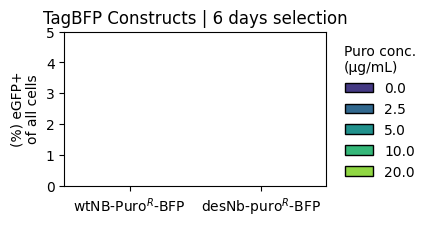

In [17]:
# General plotting params
x = 'cond'
y = 'percent'
marker_list = ['o', 's', '^', 'D', 'P', 'X']   

order = ['wtNb(mCherry)-BFP','desNb(mCherry)-BFP']

antibiotic_map = {'desNb(mCherry)-BFP':'puro', 'wtNb(mCherry)-BFP':'puro','desNb(mCherry)':'puro','wtNb(mCherry)':'puro'}


label_map = {'desNb(mCherry)-BFP':'desNb-puro$^R$-BFP',
                  'wtNb(mCherry)-BFP':'wtNB-Puro$^R$-BFP',
                  'desNb(mCherry)':'desNb-puro$^R$',
                  'wtNb(mCherry)':'wtNB-Puro$^R$'}

df_curr = data_mCH_percent_reps.loc[(data_mCH_percent_reps.cond == 'desNb(mCherry)-BFP') | (data_mCH_percent_reps.cond == 'wtNb(mCherry)-BFP')]

hue = 'puro'
Puro_conds = np.array([0,2.5,5,10,20])

# enforce ordering based on Puro_conds
hue_order = [str(p) for p in Puro_conds if p in df_curr[hue].unique()]

# What to plot
fig, ax = plt.subplots(1, 1, figsize=(4, 2))

# Plot
sns.barplot(
    ax=ax, data=df_curr,
    x=x, y=y, ci=None, hue=hue,hue_order=hue_order,
    order=order,
    palette=palette, alpha=1)


# Plot tech reps
for (j, Date) in enumerate(df_curr.biorep.unique()):
    sns.stripplot(
        ax=ax, data=df_curr[(df_curr.biorep == Date)],
        x=x, y=y, hue=hue, hue_order=hue_order,
        order=order,
        dodge=True, marker=marker_list[j],
        palette={puro: 'white' for puro in hue_order},
        size=5,
        edgecolor='black',
        linewidth=0.4,
    )

# Create colors matching the barplot
colors = sns.color_palette('viridis', n_colors=len(hue_order))

legend_handles = [
    Patch(facecolor=color, edgecolor='black', label=str(puro))
    for color, puro in zip(colors, hue_order)
]

# Remove existing legend
if ax.get_legend() is not None:
    ax.get_legend().remove()

ax.legend(
    handles=legend_handles,
    title='Puro conc.\n(µg/mL)',
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    frameon=False
)

# Formatting
ax.yaxis.set_label_text('(%) eGFP+\nof all cells')
ax.set_ylim((0, 5))

# Title
ax.set_title('TagBFP Constructs | 6 days selection')
ax.axhline(100, 0, 1, color='grey', linestyle='--')
ax.set_xlabel('')
ax.set_xticklabels([label_map[l] for l in order])

# Add barplot labels
for sub_ax in plt.gcf().get_axes():
    for i in sub_ax.containers:
        bar_labels = sub_ax.bar_label(i, fmt='%0.0f', padding=5)
        for label in bar_labels:
            label.set_bbox(
                dict(facecolor='white', alpha=0.75, linewidth=0, pad=1)
            )

# Make room for legend
fig.subplots_adjust(right=0.78)

plottitle = 'Figure_BFP_mCH_percent.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')


C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_12928\3750303679.py:28: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_12928\3750303679.py:76: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label_map[l] for l in order])


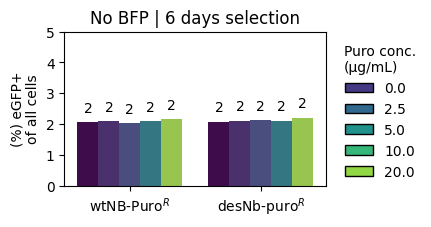

In [138]:
# General plotting params
x = 'cond'
y = 'percent'
marker_list = ['o', 's', '^', 'D', 'P', 'X']   

order = ['wtNb(mCherry)','desNb(mCherry)']

antibiotic_map = {'desNb(mCherry)-BFP':'puro', 'wtNb(mCherry)-BFP':'puro','desNb(mCherry)':'puro','wtNb(mCherry)':'puro'}


label_map = {'desNb(mCherry)-BFP':'desNb-puro$^R$-BFP',
                  'wtNb(mCherry)-BFP':'wtNB-Puro$^R$-BFP',
                  'desNb(mCherry)':'desNb-puro$^R$',
                  'wtNb(mCherry)':'wtNB-Puro$^R$'}

df_curr = data_mCH_percent_reps.loc[(data_mCH_percent_reps.cond == 'desNb(mCherry)') | (data_mCH_percent_reps.cond == 'wtNb(mCherry)')]
palette = viridis_no_yellow
hue = 'puro'
Puro_conds = np.array([0,2.5,5,10,20])

# enforce ordering based on Puro_conds
hue_order = [str(p) for p in Puro_conds if p in df_curr[hue].unique()]

# What to plot
fig, ax = plt.subplots(1, 1, figsize=(4, 2))

# Plot
sns.barplot(
    ax=ax, data=df_curr,
    x=x, y=y, ci=None, hue=hue,hue_order=hue_order,
    order=order,
    palette=palette, alpha=1)


# Plot tech reps
for (j, Date) in enumerate(df_curr.biorep.unique()):
    sns.stripplot(
        ax=ax, data=df_curr[(df_curr.biorep == Date)],
        x=x, y=y, hue=hue, hue_order=hue_order,
        order=order,
        dodge=True, marker=marker_list[j],
        palette={puro: 'white' for puro in hue_order},
        size=5,
        edgecolor='black',
        linewidth=0.4,
    )

# Create colors matching the barplot
colors = sns.color_palette("viridis", n_colors=len(hue_order))

legend_handles = [
    Patch(facecolor=color, edgecolor='black', label=str(puro))
    for color, puro in zip(colors, hue_order)
]

# Remove existing legend
if ax.get_legend() is not None:
    ax.get_legend().remove()

ax.legend(
    handles=legend_handles,
    title='Puro conc.\n(µg/mL)',
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    frameon=False
)

# Formatting
ax.yaxis.set_label_text('(%) eGFP+\nof all cells')
ax.set_ylim((0, 5))

# Title
ax.set_title('No BFP | 6 days selection')
# ax.axhline(100, 0, 1, color='grey', linestyle='--')
ax.set_xlabel('')
ax.set_xticklabels([label_map[l] for l in order])

# Add barplot labels
for sub_ax in plt.gcf().get_axes():
    for i in sub_ax.containers:
        bar_labels = sub_ax.bar_label(i, fmt='%0.0f', padding=5)
        for label in bar_labels:
            label.set_bbox(
                dict(facecolor='white', alpha=0.75, linewidth=0, pad=1)
            )

# Make room for legend
fig.subplots_adjust(right=0.78)

plottitle = 'Figure_noBFP_mCH_percent.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')


## Figure mCH - mCH+ counts

In [18]:
display(data_mCH_count_reps)

,cond,puro,biorep,well,mCH_cat,count,total_cells
0,desNb(mCherry),0.0,1,E1,mCH+,927,43199
1,desNb(mCherry),0.0,1,E1,mCH-,42272,43199
2,desNb(mCherry),0.0,1,F1,mCH+,1129,62608
3,desNb(mCherry),0.0,1,F1,mCH-,61479,62608
4,desNb(mCherry),0.0,1,G1,mCH+,1126,57003
...,...,...,...,...,...,...,...
483,wtNb(mCherry)-BFP,20.0,3,B10,mCH-,62012,63312
484,wtNb(mCherry)-BFP,20.0,3,C10,mCH+,1335,56095
485,wtNb(mCherry)-BFP,20.0,3,C10,mCH-,54760,56095
486,wtNb(mCherry)-BFP,20.0,3,D10,mCH+,1107,49996


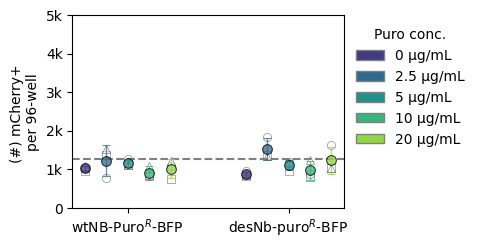

In [107]:
hue = 'puro'
hue_order = [0, 2.5, 5, 10, 20]

# General plotting params
x = 'cond'
y = 'count'

order = ['wtNb(mCherry)-BFP','desNb(mCherry)-BFP']

antibiotic_map = {'desNb(mCherry)-BFP':'puro', 'wtNb(mCherry)-BFP':'puro','desNb(mCherry)':'puro','wtNb(mCherry)':'puro'}


label_map = {'desNb(mCherry)-BFP':'desNb-puro$^R$-BFP',
                  'wtNb(mCherry)-BFP':'wtNB-Puro$^R$-BFP',
                  'desNb(mCherry)':'desNb-puro$^R$',
                  'wtNb(mCherry)':'wtNB-Puro$^R$'}

palette = sns.color_palette("viridis", len(hue_order))

subset = data_mCH_count_reps[(data_mCH_count_reps['mCH_cat'] == 'mCH+')]

# Calculate mean of biological replicate means

bio_means = (
    subset
    .groupby(['cond', 'puro', 'biorep'], as_index=False)[y]
    .mean()
)

summary = (
    bio_means
    .groupby(['cond', 'puro'], as_index=False)
    .agg(
        mean=(y, 'mean'),
        sd=(y, 'std')
    )
)

fig, ax = plt.subplots(1, 1, figsize=(3.5,2.5))

colors = sns.color_palette("viridis", len(hue_order))

# positions
group_centers = [0, 0.45]
offsets = np.linspace(-0.12, 0.12, len(hue_order))

markers = {1:'s', 2:'o', 3:'^', 0:'D'}

# Technical replicate dots (back layer)

for rep, marker in markers.items():

    rep_data = bio_means[bio_means.biorep == rep]

    for i, cond in enumerate(order):
        for j, puro in enumerate(hue_order):

            row = rep_data[
                (rep_data.cond == cond) &
                (rep_data.puro == puro)
            ]

            if row.empty:
                continue

            xloc = group_centers[i] + offsets[j]

            ax.scatter(
                xloc,
                row[y],
                marker=marker,
                s=35,
                facecolor='white',
                edgecolor='black',
                linewidth=0.5,
                alpha=alpha_tech_rep,
                zorder=2
            )

# Biological replicate mean dots (front layer)


for i, cond in enumerate(order):
    for j, puro in enumerate(hue_order):

        row = summary[
            (summary.cond == cond) &
            (summary.puro == puro)
        ]

        if row.empty:
            continue

        xloc = group_centers[i] + offsets[j]

        ax.errorbar(
            xloc,
            row['mean'].iloc[0],
            yerr=row['sd'].iloc[0],
            fmt='o',
            markersize=markersize,
            color=colors[j],
            alpha=alpha_mean,
            mec='black',
            mew=0.8,
            capsize=3,
            linewidth=1,
            zorder=5
        )

# Formatting

ax.yaxis.set_label_text('(#) mCherry+ \nper 96-well')
ax.xaxis.set_label_text('')

ax.yaxis.set_major_formatter(
    matplotlib.ticker.FuncFormatter(
        lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'
    )
)

ax.set_ylim(0,5000)

ax.set_xticks(group_centers)

ax.set_xticklabels(
    [label_map[t] for t in order],
    rotation=0
)


# Legend
legend_handles = [
    Patch(
        facecolor=colors[i],
        edgecolor='grey',
        label=f'{p} µg/mL'
    )
    for i, p in enumerate(hue_order)
]

ax.legend(
    handles=legend_handles,
    title='Puro conc.',
    loc='upper left',
    bbox_to_anchor=(1,1),
    frameon=False
)

ax.axhline(means_mCH['none'], color='grey', linestyle='--')

plottitle = 'Figure_XX_mCherry_count_dots.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')

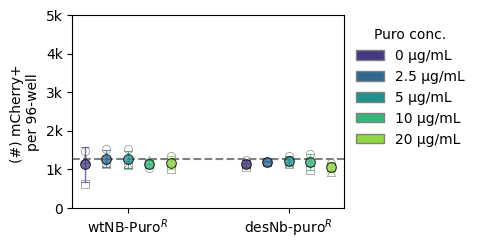

In [108]:
hue = 'puro'
hue_order = [0, 2.5, 5, 10, 20]

# General plotting params
x = 'cond'
y = 'count'

order = ['wtNb(mCherry)','desNb(mCherry)']

antibiotic_map = {'desNb(mCherry)-BFP':'puro', 'wtNb(mCherry)-BFP':'puro','desNb(mCherry)':'puro','wtNb(mCherry)':'puro'}


label_map = {'desNb(mCherry)-BFP':'desNb-puro$^R$-BFP',
                  'wtNb(mCherry)-BFP':'wtNB-Puro$^R$-BFP',
                  'desNb(mCherry)':'desNb-puro$^R$',
                  'wtNb(mCherry)':'wtNB-Puro$^R$'}


subset = data_mCH_count_reps[(data_mCH_count_reps['mCH_cat'] == 'mCH+')]


# Calculate mean of biological replicate means

bio_means = (
    subset
    .groupby(['cond', 'puro', 'biorep'], as_index=False)[y]
    .mean()
)

summary = (
    bio_means
    .groupby(['cond', 'puro'], as_index=False)
    .agg(
        mean=(y, 'mean'),
        sd=(y, 'std')
    )
)

fig, ax = plt.subplots(1, 1, figsize=(3.5,2.5))

colors = sns.color_palette("viridis", len(hue_order))

# positions
group_centers = [0,0.45]
offsets = np.linspace(-0.12, 0.12, len(hue_order))

markers = {1:'s', 2:'o', 3:'^', 0:'D'}

# Technical replicate dots (back layer)

for rep, marker in markers.items():

    rep_data = bio_means[bio_means.biorep == rep]

    for i, cond in enumerate(order):
        for j, puro in enumerate(hue_order):

            row = rep_data[
                (rep_data.cond == cond) &
                (rep_data.puro == puro)
            ]

            if row.empty:
                continue

            xloc = group_centers[i] + offsets[j]

            ax.scatter(
                xloc,
                row[y],
                marker=marker,
                s=35,
                facecolor='white',
                edgecolor='black',
                linewidth=0.5,
                alpha=alpha_tech_rep,
                zorder=2
            )

# Biological replicate mean dots (front layer)


for i, cond in enumerate(order):
    for j, puro in enumerate(hue_order):

        row = summary[
            (summary.cond == cond) &
            (summary.puro == puro)
        ]

        if row.empty:
            continue

        xloc = group_centers[i] + offsets[j]

        ax.errorbar(
            xloc,
            row['mean'].iloc[0],
            yerr=row['sd'].iloc[0],
            fmt='o',
            markersize=markersize,
            color=colors[j],
            alpha=alpha_mean,
            mec='black',
            mew=0.8,
            capsize=3,
            linewidth=1,
            zorder=5
        )

# Formatting

ax.yaxis.set_label_text('(#) mCherry+ \nper 96-well')
ax.xaxis.set_label_text('')

ax.yaxis.set_major_formatter(
    matplotlib.ticker.FuncFormatter(
        lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'
    )
)

ax.set_ylim(0,5000)

ax.set_xticks(group_centers)

ax.set_xticklabels(
    [label_map[t] for t in order],
    rotation=0
)


# Legend
legend_handles = [
    Patch(
        facecolor=colors[i],
        edgecolor='grey',
        label=f'{p} µg/mL'
    )
    for i, p in enumerate(hue_order)
]

ax.legend(
    handles=legend_handles,
    title='Puro conc.',
    loc='upper left',
    bbox_to_anchor=(1,1),
    frameon=False
)
ax.axhline(means_mCH['none'], color='grey', linestyle='--')

plottitle = 'Figure_XX_mCherry_count_noBFP_dots.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')

## Figure mCH - Transduced cell counts

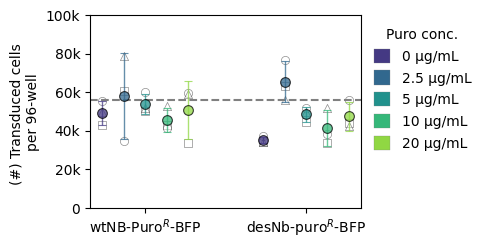

In [75]:
hue = 'puro'
hue_order = [0, 2.5, 5, 10, 20]

# General plotting params
x = 'cond'
y = 'count'

order = ['wtNb(mCherry)-BFP','desNb(mCherry)-BFP']

antibiotic_map = {'desNb(mCherry)-BFP':'puro', 'wtNb(mCherry)-BFP':'puro','desNb(mCherry)':'puro','wtNb(mCherry)':'puro'}


label_map = {'desNb(mCherry)-BFP':'desNb-puro$^R$-BFP',
                  'wtNb(mCherry)-BFP':'wtNB-Puro$^R$-BFP',
                  'desNb(mCherry)':'desNb-puro$^R$',
                  'wtNb(mCherry)':'wtNB-Puro$^R$'}


subset = data_iRFP670_count_reps[(data_iRFP670_count_reps['iRFP670_cat'] == 'iRFP670+')]


# Calculate mean of biological replicate means

bio_means = (
    subset
    .groupby(['cond', 'puro', 'biorep'], as_index=False)[y]
    .mean()
)

summary = (
    bio_means
    .groupby(['cond', 'puro'], as_index=False)
    .agg(
        mean=(y, 'mean'),
        sd=(y, 'std')
    )
)

fig, ax = plt.subplots(1, 1, figsize=(3.5,2.5))

colors = sns.color_palette("viridis", len(hue_order))
# positions
group_centers = [0, 0.45]
offsets = np.linspace(-0.12, 0.12, len(hue_order))

markers = {1:'s', 2:'o', 3:'^', 0:'D'}

# Technical replicate dots (back layer)

for rep, marker in markers.items():

    rep_data = bio_means[bio_means.biorep == rep]

    for i, cond in enumerate(order):
        for j, puro in enumerate(hue_order):

            row = rep_data[
                (rep_data.cond == cond) &
                (rep_data.puro == puro)
            ]

            if row.empty:
                continue

            xloc = group_centers[i] + offsets[j]

            ax.scatter(
                xloc,
                row[y],
                marker=marker,
                s=35,
                facecolor='white',
                edgecolor='black',
                linewidth=0.5,
                alpha=alpha_tech_rep,
                zorder=2
            )

# Biological replicate mean dots (front layer)


for i, cond in enumerate(order):
    for j, puro in enumerate(hue_order):

        row = summary[
            (summary.cond == cond) &
            (summary.puro == puro)
        ]

        if row.empty:
            continue

        xloc = group_centers[i] + offsets[j]

        ax.errorbar(
            xloc,
            row['mean'].iloc[0],
            yerr=row['sd'].iloc[0],
            fmt='o',
            markersize=markersize,
            color=colors[j],
            alpha=alpha_mean,
            mec='black',
            mew=0.8,
            capsize=3,
            linewidth=1,
            zorder=5
        )

# Formatting

ax.yaxis.set_label_text('(#) Transduced cells \nper 96-well')
ax.xaxis.set_label_text('')

ax.yaxis.set_major_formatter(
    matplotlib.ticker.FuncFormatter(
        lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'
    )
)

ax.set_ylim(0,100000)

ax.set_xticks(group_centers)

ax.set_xticklabels(
    [label_map[t] for t in order],
    rotation=0
)



# Legend
legend_handles = [
    Patch(
        facecolor=colors[i],
        edgecolor='grey',
        label=f'{p} µg/mL', linewidth = 0.2
    )
    for i, p in enumerate(hue_order)
]

ax.legend(
    handles=legend_handles,
    title='Puro conc.',
    loc='upper left',
    bbox_to_anchor=(1,1),
    frameon=False,
    handleheight = 1.2,
    handlelength = 1.2
)
ax.axhline(means['none'], color='grey', linestyle='--')

plottitle = 'Figure_XX_mCherry_total_transduced.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')

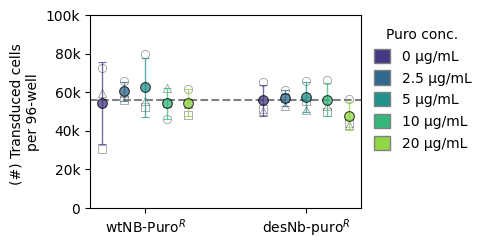

In [76]:
hue = 'puro'
hue_order = [0, 2.5, 5, 10, 20]

# General plotting params
x = 'cond'
y = 'count'

order = ['wtNb(mCherry)','desNb(mCherry)']

antibiotic_map = {'desNb(mCherry)-BFP':'puro', 'wtNb(mCherry)-BFP':'puro','desNb(mCherry)':'puro','wtNb(mCherry)':'puro'}


label_map = {'desNb(mCherry)-BFP':'desNb-puro$^R$-BFP',
                  'wtNb(mCherry)-BFP':'wtNB-Puro$^R$-BFP',
                  'desNb(mCherry)':'desNb-puro$^R$',
                  'wtNb(mCherry)':'wtNB-Puro$^R$'}
subset = data_iRFP670_count_reps[(data_iRFP670_count_reps['iRFP670_cat'] == 'iRFP670+')]

colors = sns.color_palette("viridis", len(hue_order))
# Calculate mean of biological replicate means

bio_means = (
    subset
    .groupby(['cond', 'puro', 'biorep'], as_index=False)[y]
    .mean()
)

summary = (
    bio_means
    .groupby(['cond', 'puro'], as_index=False)
    .agg(
        mean=(y, 'mean'),
        sd=(y, 'std')
    )
)

fig, ax = plt.subplots(1, 1, figsize=(3.5,2.5))

# positions
group_centers = [0,0.45]
offsets = np.linspace(-0.12, 0.12, len(hue_order))

markers = {1:'s', 2:'o', 3:'^', 0:'D'}

# Technical replicate dots (back layer)

for rep, marker in markers.items():

    rep_data = bio_means[bio_means.biorep == rep]

    for i, cond in enumerate(order):
        for j, puro in enumerate(hue_order):

            row = rep_data[
                (rep_data.cond == cond) &
                (rep_data.puro == puro)
            ]

            if row.empty:
                continue

            xloc = group_centers[i] + offsets[j]

            ax.scatter(
                xloc,
                row[y],
                marker=marker,
                s=35,
                facecolor='white',
                edgecolor='black',
                linewidth=0.5,
                alpha=alpha_tech_rep,
                zorder=2
            )

# Biological replicate mean dots (front layer)


for i, cond in enumerate(order):
    for j, puro in enumerate(hue_order):

        row = summary[
            (summary.cond == cond) &
            (summary.puro == puro)
        ]

        if row.empty:
            continue

        xloc = group_centers[i] + offsets[j]

        ax.errorbar(
            xloc,
            row['mean'].iloc[0],
            yerr=row['sd'].iloc[0],
            fmt='o',
            markersize=markersize,
            color=colors[j],
            alpha=alpha_mean,
            mec='black',
            mew=0.8,
            capsize=3,
            linewidth=1,
            zorder=5
        )

# Formatting

ax.yaxis.set_label_text('(#) Transduced cells \nper 96-well')
ax.xaxis.set_label_text('')

ax.yaxis.set_major_formatter(
    matplotlib.ticker.FuncFormatter(
        lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'
    )
)

ax.set_ylim(0,100000)

ax.set_xticks(group_centers)

ax.set_xticklabels(
    [label_map[t] for t in order],
    rotation=0
)


# Legend
legend_handles = [
    Patch(
        facecolor=colors[i],
        edgecolor='grey',
        label=f'{p} µg/mL'
    )
    for i, p in enumerate(hue_order)
]

ax.legend(
    handles=legend_handles,
    title='Puro conc.',
    loc='upper left',
    bbox_to_anchor=(1,1),
    frameon=False,
    handleheight = 1.2,
    handlelength = 1.2
)

ax.axhline(means['none'], color='grey', linestyle='--')

plottitle = 'Figure_XX_mCherry_total_transduced_noBFP.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')

## Figure mCH - Joint distributions

C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_14384\1152640270.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()  # Helps improve white spacing


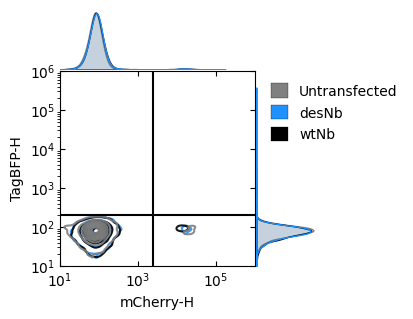

In [51]:
# General plotting params
x = "mCherry-H"
y = "TagBFP-H"
hue = "cond"

hue_order = ['desNb(mCherry)','wtNb(mCherry)','none']

# Conditions

palette = {'desNb(mCherry)-BFP':'dodgerblue',
                  'wtNb(mCherry)-BFP':'black',
                  'desNb(mCherry)':'dodgerblue',
                  'wtNb(mCherry)':'black',
                  'none': 'grey'}

# Conditions
data_new = data[(data['mCherry-H'] > 0 ) & (data['TagBFP-H'] > 0) & (data['puro'] == 0)]
untransfected = data[(data['mCherry-H'] > 0 ) & (data['TagBFP-H'] > 0) & (data['puro'] == 0) & (data['cond'] == 'none')]

# only look at no selection and iRFP+ infected
small_data = pd.concat([data_new,untransfected])
small_data= small_data.groupby('cond').sample(n=5000, random_state=7)


# definitions for the axes
left, width = 0.1, 0.65
bottom, height = 0.1, 0.65
spacing = 0.005

rect_scatter = [left, bottom, width, height]
rect_histx = [left, bottom + height + spacing, width, 0.2]
rect_histy = [left + width + spacing, bottom, 0.2, height]

# Set up figure
fig = plt.figure(figsize=(3,3))
ax_scatter = plt.axes(rect_scatter)
ax_scatter.tick_params(direction="in", top=True, right=True)
ax_histx = plt.axes(rect_histx)
ax_histx.set_axis_off()
ax_histy = plt.axes(rect_histy)
ax_histy.set_axis_off()

# Set limits
mRuby2_lim = (10, 1e6)
mCherry_lim = (10, 1e6)
ylim = mRuby2_lim
xlim = mCherry_lim
ax_scatter.set_xlim(xlim)
ax_scatter.set_ylim(ylim)
ax_histx.set_xlim(xlim)
ax_histy.set_ylim(ylim)

# Make density plots
sns.kdeplot(
    ax=ax_scatter,
    data=small_data,
    x=x, y=y, hue=hue, hue_order=hue_order,
    alpha=0.9, palette=palette,
    log_scale=True, common_norm=False, fill=False, legend=False,
)

# Plot histograms
ax_histx = sns.kdeplot(ax=ax_histx,
    data=small_data, x=x,
    hue=hue, hue_order=hue_order,
    alpha=0.1, palette=palette,
    log_scale=True, fill=True, common_norm=False, legend=False,
)
sns.kdeplot(
    ax=ax_histy,
    data=small_data,y=y,
    hue=hue, hue_order=hue_order,
    alpha=0.1, palette=palette,
    log_scale=True, fill=True, common_norm=False, legend=False,
)

# h,l = ax_histx.get_legend_handles_labels()
# sns.move_legend(ax_histx, handles=h, labels=l,
#     title='', loc='upper left', bbox_to_anchor=(1,1), frameon=False)
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor='grey', edgecolor='black', linewidth=0.2,
          label='Untransfected'),
    Patch(facecolor='dodgerblue', edgecolor='black', linewidth=0.2,
          label='desNb'),
    Patch(facecolor='black', edgecolor='black', linewidth=0.2,
          label='wtNb')
]

ax_scatter.legend(
    handles=legend_elements,
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    frameon=False,
    handlelength=1.2,
    handleheight=1.2
)
# Threshold
ax_scatter.axvline(mRuby2_gate, 0, 1, color='black')
ax_scatter.axhline(TagBFP_gate, 0, 1, color='black')

fig.tight_layout()  # Helps improve white spacing

plottitle = 'Figure_noBFP_contour.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')

C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_14384\1292116775.py:104: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()  # Helps improve white spacing


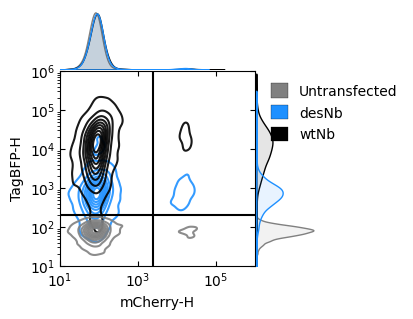

In [52]:
# General plotting params
x = "mCherry-H"
y = "TagBFP-H"
hue = "cond"

hue_order = ['desNb(mCherry)-BFP','wtNb(mCherry)-BFP','none']

# Conditions
palette = {'desNb(mCherry)-BFP':'dodgerblue',
                  'wtNb(mCherry)-BFP':'black',
                  'desNb(mCherry)':'dodgerblue',
                  'wtNb(mCherry)':'black',
                  'none': 'grey'}


# Conditions
data_new = data[(data['mCherry-H'] > 0 ) & (data['TagBFP-H'] > 0) & (data['puro'] == 20)]
untransfected = data[(data['mCherry-H'] > 0 ) & (data['TagBFP-H'] > 0) & (data['puro'] == 0) & (data['cond'] == 'none')]

# only look at no selection and iRFP+ infected
small_data = pd.concat([data_new,untransfected])
small_data= small_data.groupby('cond').sample(n=5000, random_state=7)


# definitions for the axes
left, width = 0.1, 0.65
bottom, height = 0.1, 0.65
spacing = 0.005

rect_scatter = [left, bottom, width, height]
rect_histx = [left, bottom + height + spacing, width, 0.2]
rect_histy = [left + width + spacing, bottom, 0.2, height]

# Set up figure
fig = plt.figure(figsize=(3,3))
ax_scatter = plt.axes(rect_scatter)
ax_scatter.tick_params(direction="in", top=True, right=True)
ax_histx = plt.axes(rect_histx)
ax_histx.set_axis_off()
ax_histy = plt.axes(rect_histy)
ax_histy.set_axis_off()

# Set limits
mRuby2_lim = (10, 1e6)
mCherry_lim = (10, 1e6)
ylim = mRuby2_lim
xlim = mCherry_lim
ax_scatter.set_xlim(xlim)
ax_scatter.set_ylim(ylim)
ax_histx.set_xlim(xlim)
ax_histy.set_ylim(ylim)

# Make density plots
sns.kdeplot(
    ax=ax_scatter,
    data=small_data,
    x=x, y=y, hue=hue, hue_order=hue_order,
    alpha=0.9, palette=palette,
    log_scale=True, common_norm=False, fill=False, legend=False,
)

# Plot histograms
ax_histx = sns.kdeplot(ax=ax_histx,
    data=small_data, x=x,
    hue=hue, hue_order=hue_order,
    alpha=0.1, palette=palette,
    log_scale=True, fill=True, common_norm=False, legend=False,
)
sns.kdeplot(
    ax=ax_histy,
    data=small_data,y=y,
    hue=hue, hue_order=hue_order,
    alpha=0.1, palette=palette,
    log_scale=True, fill=True, common_norm=False, legend=False,
)

# h,l = ax_histx.get_legend_handles_labels()
# sns.move_legend(ax_histx, handles=h, labels=l,
#     title='', loc='upper left', bbox_to_anchor=(1,1), frameon=False)
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor='grey', edgecolor='black',linewidth=0.2,
          label='Untransfected'),
    Patch(facecolor='dodgerblue', edgecolor='black',linewidth=0.2,
          label='desNb'),
    Patch(facecolor='black', edgecolor='black', linewidth=0.2,
          label='wtNb')
]


ax_scatter.legend(
    handles=legend_elements,
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    frameon=False,
    handlelength=1.2,
    handleheight=1.2
)
# Threshold
ax_scatter.axvline(mRuby2_gate, 0, 1, color='black')
ax_scatter.axhline(TagBFP_gate, 0, 1, color='black')

fig.tight_layout()  # Helps improve white spacing

plottitle = 'Figure_BFP_contour.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')